# FOMC Two-Leg Vol Steepener — Trade Ticket

**Trade**: LONG ZT (2Y straddle) / SHORT ZB (30Y straddle), ATM-forward,
same post-FOMC weekly expiry.  Sized to yield-vega neutrality.

**Pricer**: Bachelier (normal-vol), in-house only.
Cross-check against OMON / company pricer using the HANDOFF block.

---
| | LEG 1 | LEG 2 |
|---|---|---|
| Side | **BUY** | **SELL** |
| Instrument | ZT (2Y T-Note futures) | ZB (30Y T-Bond futures) |
| Face/contract | $200,000 | $100,000 |
| Gamma | LONG | SHORT |
| Theta | COST | INCOME |
| Sizing | Solved (vega-neutral) | Anchor ($50M) |

**Signal input**: GapSpread = Gap(SHY) − Gap(TLT), where Gap = RV_event_var − IV_event_var.
Positive GapSpread → 2Y event vol cheap relative to 30Y → BUY FRONT / SELL LONG.

In [1]:

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except (NameError, AttributeError):
    import matplotlib
    matplotlib.use("Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from trade_ticket import (
    CFG, compute_trade_ticket,
    sigma_price_from_event_sd, straddle_ticket, run_event_mc,
    solve_notional_vega_neutral, b_straddle,
)

## Configuration

All levels below are **PLACEHOLDER**.  Before submitting:
1. Set `ENTRY_DATE` (today), `FOMC_DATE` (next FOMC Wednesday), `EXPIRY_DATE`
   (post-FOMC weekly expiry from OMON) — `T_CALENDAR_DAYS` is derived automatically
2. Overwrite `F_2Y_PTS`, `F_30Y_PTS`, `Y_2Y_PCT`, `Y_30Y_PCT` from OMON screen
3. Overwrite `DV01_2Y_PER_1M`, `DV01_30Y_PER_1M` from OMON (exact futures DV01)
4. Set `SIGMA_N_2Y_OVERRIDE` / `SIGMA_N_30Y_OVERRIDE` = OMON ATM IV (for premium)
5. Set `SIGMA_2Y_YIELD_BPS_DAY` / `SIGMA_30Y_YIELD_BPS_DAY` from GapSpread model
   (or use ETF pipeline values — see the last cell)

### Date timeline

```
ENTRY_DATE ──────────────────── FOMC_DATE ──── EXPIRY_DATE
  (today / trade entry)        (Wed 2pm)       (following Friday)
        ↑                           ↑                 ↑
 T_CALENDAR_DAYS = (EXPIRY_DATE − ENTRY_DATE).days  (derived, not set)
```

The expiry is the **post-FOMC weekly option** listed on OMON, not the nearest
Friday. FOMC Wed → same-week Friday = 2 days (too short). FOMC Wed → next Friday = 9 days.

In [2]:

result = compute_trade_ticket(CFG)


══════════════════════════════════════════════════════════════════
  FOMC TWO-LEG VOL STEEPENER  ·  TRADE TICKET
══════════════════════════════════════════════════════════════════
  Generated : 2026-06-24   |   Pricer: Bachelier (normal-vol, in-house)
  Entry date: 2026-06-24   │   FOMC date : YYYY-MM-DD  ← SET FOMC_DATE  (?d away)
  Expiry    : YYYY-MM-DD  ← SET EXPIRY_DATE   │   T to expiry: 9 calendar days  (0.02466 yr)
  Vol source: event-SD derived  |  ⚠  OVERWRITE LEVELS FROM OMON / SCREEN BEFORE TRADING
══════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────
  LEG 1 — BUY ZT (2Y) STRADDLE  [LONG GAMMA, LONG VEGA]
──────────────────────────────────────────────────────────────────
  Side                            BUY
  Underlying                      ZT  (2Y T-Note Futures,  $200k face/contract)
  Forward (px)                    102.500 pts
  Strike (px)                     102.500 pts   ≈  4.7500% yi

## Monte Carlo P&L Distribution

Event-dominant: one FOMC jump per path, no diffusive hedge.
Yield moves drawn from bivariate normal (ρ = 0.35).

The short 30Y leg has **open-ended loss** if 30Y rates move sharply —
the ES99 on that leg sets the hard stop level.

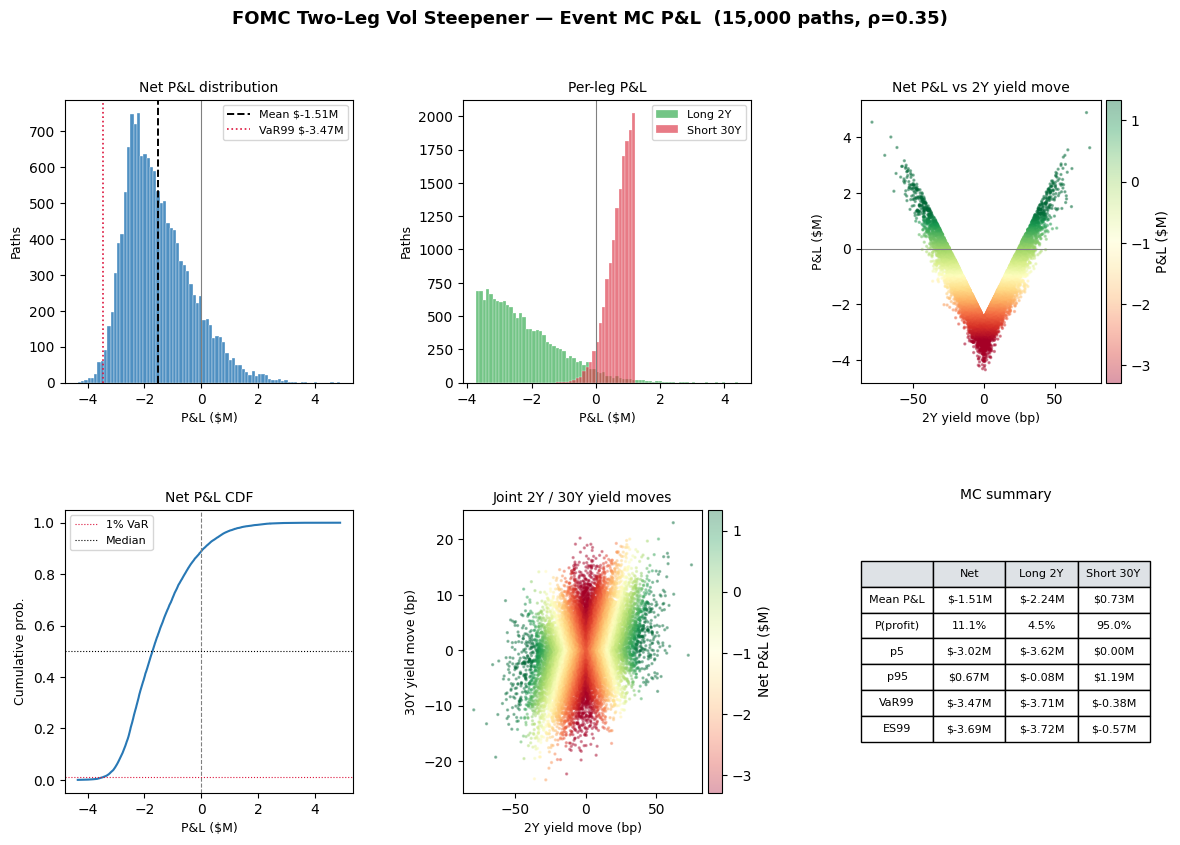

Saved: fomc_viz/fig_trade_ticket_mc.png


In [3]:

mc     = result["mc"]
pnl_n  = mc["_pnl_net"]   / 1e6   # convert to $M
pnl_2y = mc["_pnl_2y"]    / 1e6
pnl_30 = mc["_pnl_30y"]   / 1e6
dy_2y  = mc["_dy_2y"]             # bp
dy_30y = mc["_dy_30y"]            # bp

fig = plt.figure(figsize=(14, 9))
fig.suptitle(
    "FOMC Two-Leg Vol Steepener — Event MC P&L  "
    f"({CFG['N_PATHS']:,} paths, ρ={CFG['RHO_2Y_30Y']})",
    fontsize=13, fontweight="bold", y=0.98,
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── [0,0] Net P&L histogram ──────────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(pnl_n, bins=80, color="#2878b5", alpha=0.82, edgecolor="white", linewidth=0.3)
ax0.axvline(pnl_n.mean(),      color="k",   lw=1.4, ls="--", label=f"Mean ${pnl_n.mean():.2f}M")
ax0.axvline(np.percentile(pnl_n, 1), color="crimson", lw=1.2, ls=":", label=f"VaR99 ${np.percentile(pnl_n,1):.2f}M")
ax0.axvline(0, color="grey", lw=0.8, ls="-")
ax0.set_title("Net P&L distribution", fontsize=10)
ax0.set_xlabel("P&L ($M)", fontsize=9); ax0.set_ylabel("Paths", fontsize=9)
ax0.legend(fontsize=8)

# ── [0,1] Per-leg P&L overlaid ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
bins = np.linspace(min(pnl_2y.min(), pnl_30.min()), max(pnl_2y.max(), pnl_30.max()), 80)
ax1.hist(pnl_2y, bins=bins, alpha=0.65, color="#28a745", label="Long 2Y", edgecolor="white", lw=0.3)
ax1.hist(pnl_30, bins=bins, alpha=0.65, color="#dc3545", label="Short 30Y", edgecolor="white", lw=0.3)
ax1.axvline(0, color="grey", lw=0.8)
ax1.set_title("Per-leg P&L", fontsize=10)
ax1.set_xlabel("P&L ($M)", fontsize=9); ax1.set_ylabel("Paths", fontsize=9)
ax1.legend(fontsize=8)

# ── [0,2] Net P&L vs 2Y yield move (convexity scatter) ───────────────────────
ax2 = fig.add_subplot(gs[0, 2])
sc = ax2.scatter(dy_2y, pnl_n, c=pnl_n, cmap="RdYlGn", s=2, alpha=0.4,
                 vmin=np.percentile(pnl_n, 2), vmax=np.percentile(pnl_n, 98))
ax2.axhline(0, color="grey", lw=0.8)
ax2.set_title("Net P&L vs 2Y yield move", fontsize=10)
ax2.set_xlabel("2Y yield move (bp)", fontsize=9); ax2.set_ylabel("P&L ($M)", fontsize=9)
plt.colorbar(sc, ax=ax2, label="P&L ($M)", pad=0.02)

# ── [1,0] CDF: net P&L ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
sorted_n = np.sort(pnl_n)
cdf = np.arange(1, len(sorted_n) + 1) / len(sorted_n)
ax3.plot(sorted_n, cdf, color="#2878b5", lw=1.5)
ax3.axvline(0, color="grey", lw=0.8, ls="--")
ax3.axhline(0.01, color="crimson", lw=0.8, ls=":", label="1% VaR")
ax3.axhline(0.50, color="k",       lw=0.8, ls=":", label="Median")
ax3.set_title("Net P&L CDF", fontsize=10)
ax3.set_xlabel("P&L ($M)", fontsize=9); ax3.set_ylabel("Cumulative prob.", fontsize=9)
ax3.legend(fontsize=8)

# ── [1,1] Joint yield-move scatter coloured by net P&L ───────────────────────
ax4 = fig.add_subplot(gs[1, 1])
sc2 = ax4.scatter(dy_2y, dy_30y, c=pnl_n, cmap="RdYlGn", s=2, alpha=0.35,
                  vmin=np.percentile(pnl_n, 2), vmax=np.percentile(pnl_n, 98))
ax4.set_title("Joint 2Y / 30Y yield moves", fontsize=10)
ax4.set_xlabel("2Y yield move (bp)", fontsize=9)
ax4.set_ylabel("30Y yield move (bp)", fontsize=9)
plt.colorbar(sc2, ax=ax4, label="Net P&L ($M)", pad=0.02)

# ── [1,2] Summary table ───────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
rows = [
    ["", "Net", "Long 2Y", "Short 30Y"],
    ["Mean P&L", f"${pnl_n.mean():.2f}M", f"${pnl_2y.mean():.2f}M", f"${pnl_30.mean():.2f}M"],
    ["P(profit)", f"{(pnl_n>0).mean():.1%}", f"{(pnl_2y>0).mean():.1%}", f"{(pnl_30>0).mean():.1%}"],
    ["p5",  f"${np.percentile(pnl_n,5):.2f}M", f"${np.percentile(pnl_2y,5):.2f}M", f"${np.percentile(pnl_30,5):.2f}M"],
    ["p95", f"${np.percentile(pnl_n,95):.2f}M", f"${np.percentile(pnl_2y,95):.2f}M", f"${np.percentile(pnl_30,95):.2f}M"],
    ["VaR99", f"${np.percentile(pnl_n,1):.2f}M", f"${np.percentile(pnl_2y,1):.2f}M", f"${np.percentile(pnl_30,1):.2f}M"],
    ["ES99",  f"${mc['net']['es99']/1e6:.2f}M",  f"${mc['leg2y']['es99']/1e6:.2f}M", f"${mc['leg30y']['es99']/1e6:.2f}M"],
]
col_colors = [["#dee2e6"]*4] + [["white"]*4]*6
tbl = ax5.table(cellText=rows[1:], colLabels=rows[0],
                loc="center", cellLoc="center",
                colColours=["#dee2e6"]*4)
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
tbl.scale(1.0, 1.55)
ax5.set_title("MC summary", fontsize=10, pad=8)

import os
os.makedirs("fomc_viz", exist_ok=True)
plt.savefig("fomc_viz/fig_trade_ticket_mc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fomc_viz/fig_trade_ticket_mc.png")

## Vega-neutral vs gamma-neutral sizing comparison

| Sizing | 2Y Notional | Ratio vs 30Y | Thesis |
|--------|------------|--------------|--------|
| Vega-neutral | `N_30Y × DV01_30Y / DV01_2Y` | ≈ DV01 ratio (11.8×) | IV spread reprices |
| Gamma-neutral | `N_30Y × γ_30Y / γ_2Y` | ≈ 0.25× | RV front-move > priced |

Use **vega-neutral** when the GapSpread signal measures implied vol spread (default).
Switch to **gamma-neutral** only if the thesis is a realised-vol surprise on the event day.

In [4]:

T    = result["T"]       # derived from ENTRY_DATE / EXPIRY_DATE
T_cd = result["T_days"]
dv01_2y  = CFG["DV01_2Y_PER_1M"]
dv01_30y = CFG["DV01_30Y_PER_1M"]
sigma_n_2y  = sigma_price_from_event_sd(CFG["SIGMA_2Y_YIELD_BPS_DAY"], dv01_2y)
sigma_n_30y = sigma_price_from_event_sd(CFG["SIGMA_30Y_YIELD_BPS_DAY"], dv01_30y)

# Sweep: 2Y event SD ± 50% while holding 30Y fixed
sd2_base = CFG["SIGMA_2Y_YIELD_BPS_DAY"]
sd30     = CFG["SIGMA_30Y_YIELD_BPS_DAY"]
n30      = CFG["N_30Y_NOTIONAL"]
F2, K2   = CFG["F_2Y_PTS"], round(CFG["F_2Y_PTS"] / CFG["STRIKE_GRID_PTS"]) * CFG["STRIKE_GRID_PTS"]
F30, K30 = CFG["F_30Y_PTS"], round(CFG["F_30Y_PTS"] / CFG["STRIKE_GRID_PTS"]) * CFG["STRIKE_GRID_PTS"]

sweep_rows = []
for mult in [0.50, 0.70, 0.85, 1.00, 1.15, 1.30, 1.50]:
    sd2 = sd2_base * mult
    sn2  = sigma_price_from_event_sd(sd2,  dv01_2y)
    sn30 = sigma_price_from_event_sd(sd30, dv01_30y)
    tk2_  = straddle_ticket(F2, K2, T, sn2, n30, dv01_2y, CFG["FACE_ZT"])   # temp for vega
    tk30_ = straddle_ticket(F30, K30, T, sn30, n30, dv01_30y, CFG["FACE_ZB"])
    n2_vega = solve_notional_vega_neutral(
        n30, tk30_["vega_price_pts"], dv01_30y,
        b_straddle(F2, K2, T, sn2)["vega"], dv01_2y)
    tk2_v = straddle_ticket(F2, K2, T, sn2, n2_vega, dv01_2y, CFG["FACE_ZT"])
    cost2  = CFG["HALF_SPREAD_PTS"] * 0.01 * n2_vega + CFG["COMMISSION_PER_LOT"] * tk2_v["contracts"]
    cost30 = CFG["HALF_SPREAD_PTS"] * 0.01 * n30 + CFG["COMMISSION_PER_LOT"] * tk30_["contracts"]
    mc_ = run_event_mc(
        n2_vega, K2, F2, sd2, dv01_2y, tk2_v["premium_usd"], cost2,
        n30, K30, F30, sd30, dv01_30y, tk30_["premium_usd"], cost30,
        rho=CFG["RHO_2Y_30Y"], n_paths=5_000, seed=42)
    sweep_rows.append({
        "σ_2Y mult": f"{mult:.2f}×",
        "σ_2Y (bp/day)": f"{sd2:.1f}",
        "N_2Y ($M)": f"${n2_vega/1e6:.0f}M",
        "Premium net ($K)": f"${(tk2_v['premium_usd']-tk30_['premium_usd'])/1e3:+.0f}K",
        "Mean P&L ($K)": f"${mc_['net']['mean']/1e3:+.0f}K",
        "P(profit)": f"{mc_['net']['p_profit']:.0%}",
        "VaR99 ($K)": f"${mc_['net']['var99']/1e3:.0f}K",
    })

df_sweep = pd.DataFrame(sweep_rows)
print("\n── Sizing sensitivity: σ_2Y sweep (30Y fixed) ──────────────────────────")
print(df_sweep.to_string(index=False))


── Sizing sensitivity: σ_2Y sweep (30Y fixed) ──────────────────────────
σ_2Y mult σ_2Y (bp/day) N_2Y ($M) Premium net ($K) Mean P&L ($K) P(profit) VaR99 ($K)
    0.50×           9.0     $590M           $+616K        $-406K       24%    $-1754K
    0.70×          12.6     $590M          $+1355K        $-850K       16%    $-2413K
    0.85×          15.3     $590M          $+1910K       $-1183K       13%    $-2933K
    1.00×          18.0     $590M          $+2464K       $-1517K       11%    $-3448K
    1.15×          20.7     $590M          $+3019K       $-1850K       10%    $-3975K
    1.30×          23.4     $590M          $+3573K       $-2183K       10%    $-4508K
    1.50×          27.0     $590M          $+4312K       $-2627K        9%    $-5214K


## ETF pipeline signal → CFG overrides

The ETF IV pipeline (`etf_gap_curve.parquet`) provides MOVE-bridge-derived
event vols for SHY (2Y proxy) and TLT (30Y proxy).
Use these as starting values for `SIGMA_*_YIELD_BPS_DAY` before replacing
with GapSpread model output.

In [5]:

ETF_GAP_PATH = Path("etf_gap_curve.parquet")
ETF_DURATION = {"SHY": 1.9, "TLT": 16.0}

if ETF_GAP_PATH.exists():
    etf = pd.read_parquet(ETF_GAP_PATH)
    etf["meeting_date"] = pd.to_datetime(etf["meeting_date"])
    latest_dt = etf.loc[etf["has_both"], "meeting_date"].max()
    latest = etf[etf["meeting_date"] == latest_dt].set_index("etf")

    shy = latest.loc["SHY"] if "SHY" in latest.index else None
    tlt = latest.loc["TLT"] if "TLT" in latest.index else None

    if shy is not None and tlt is not None:
        def etf_to_bps(price_vol_pct, dur):
            return (price_vol_pct / dur) * 100 / np.sqrt(252)

        iv_2y_bps  = etf_to_bps(shy["iv_event_vol_pct"], ETF_DURATION["SHY"])
        iv_30y_bps = etf_to_bps(tlt["iv_event_vol_pct"], ETF_DURATION["TLT"])
        rv_2y_bps  = etf_to_bps(shy["rv_vol_pct"],       ETF_DURATION["SHY"])
        rv_30y_bps = etf_to_bps(tlt["rv_vol_pct"],       ETF_DURATION["TLT"])

        print(f"\n── ETF pipeline signal ({latest_dt.date()}) ──────────────────────────────")
        print(f"  Source: {shy['source']} / {tlt['source']}")
        print(f"  GapSpread: {shy['GapSpread_proxy']:+.6f} → {shy['spread_direction']}")
        print(f"  RV/IV (2Y):  {shy['rv_vol_pct']:.3f}% / {shy['iv_event_vol_pct']:.3f}%"
              f"  ratio = {shy['rv_vol_pct']/shy['iv_event_vol_pct']:.3f}×")
        print(f"  RV/IV (30Y): {tlt['rv_vol_pct']:.3f}% / {tlt['iv_event_vol_pct']:.3f}%"
              f"  ratio = {tlt['rv_vol_pct']/tlt['iv_event_vol_pct']:.3f}×")
        print()
        print("  ── Paste into trade_ticket.CFG ──────────────────────────────────")
        print(f"  SIGMA_2Y_YIELD_BPS_DAY  = {rv_2y_bps:.4f}   # SHY RV → yield bps/day")
        print(f"  SIGMA_30Y_YIELD_BPS_DAY = {rv_30y_bps:.4f}   # TLT RV → yield bps/day")
        sn2_etf  = sigma_price_from_event_sd(iv_2y_bps,  dv01_2y)
        sn30_etf = sigma_price_from_event_sd(iv_30y_bps, dv01_30y)
        print(f"  # IV → normal vol (if no OMON available):")
        print(f"  SIGMA_N_2Y_OVERRIDE  = {sn2_etf:.5f}   # pts/yr")
        print(f"  SIGMA_N_30Y_OVERRIDE = {sn30_etf:.5f}   # pts/yr")
        print()
        print("  ⚠  Replace SIGMA_N_*_OVERRIDE with OMON ATM IV for live trading.")
else:
    print("etf_gap_curve.parquet not found — run fomc_etf_iv_pipeline.py first.")


── ETF pipeline signal (2026-06-17) ──────────────────────────────
  Source: move_bridge / move_bridge
  GapSpread: +0.021876 → buy_front_sell_long
  RV/IV (2Y):  2.013% / 2.067%  ratio = 0.974×
  RV/IV (30Y): 8.589% / 17.110%  ratio = 0.502×

  ── Paste into trade_ticket.CFG ──────────────────────────────────
  SIGMA_2Y_YIELD_BPS_DAY  = 6.6728   # SHY RV → yield bps/day
  SIGMA_30Y_YIELD_BPS_DAY = 3.3814   # TLT RV → yield bps/day
  # IV → normal vol (if no OMON available):
  SIGMA_N_2Y_OVERRIDE  = 1.90367   # pts/yr
  SIGMA_N_30Y_OVERRIDE = 22.08216   # pts/yr

  ⚠  Replace SIGMA_N_*_OVERRIDE with OMON ATM IV for live trading.
